# 4.6 Efficiency and Resource Consumption

## Data Sources

- `../../runs/analysis/global_experiment_report.34d2c998f8e8143d.json` — authoritative builder metadata, active evaluated-artifact registry, extraction workload, and ER workload.
- `../../runs/status.json` — lifecycle timestamps and attempt counts. Internal lifecycle records are aggregated into exactly five practical stages: **Graph Construction, ER, RR, Retrieval, and QA**.
- `../../multihoprag_120/manifest.json` — workload denominators: 155 documents and 120 questions.
- The 36 active `question_metrics.904bfaacde8e272e.jsonl` files registered in the global report — 12 builders × 3 regimes × 120 questions; used for per-question latency, throughput, retrieval MRR, and QA accuracy.
- The 12 active base-run `environment.json` manifests resolved from the evaluated rows — platform, model identity, context length, and quantization metadata.
- `system_profiler SPHardwareDataType` (when available) — execution-host model, chip, core count, and installed unified memory. Serial identifiers are neither read into nor written by this notebook.

The notebook exports a complete resolved source inventory to `output/source_inventory.csv`. Registered per-question files are verified against their recorded SHA-256, schema, regime, record count, and paired coverage before analysis. All source artifacts are read-only.

## Practical analysis scope

The analysis asks four operational questions: (1) which stage dominates end-to-end runtime, (2) how much of each cumulative regime's cost each stage consumes, (3) how runtime and throughput scale with builder size within a family, and (4) whether extra cost buys better retrieval or QA. Peak memory was not instrumented during the runs; the notebook therefore reports the hardware constraint and measurement gap explicitly and does not substitute model size for measured memory.


## Analysis contract

The experiment is a cumulative cascade: **Native → ER → ER+RR**. The primary contrast is
**ER+RR−Native**, the secondary contrast is **ER−Native**, and the incremental ablation is
**ER+RR−ER**. Uncertainty is estimated by 10,000 paired, question-level bootstrap resamples
stratified by question type (seed 42), matching the evaluated analysis contract.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import platform
import re
import subprocess
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

start = Path.cwd().resolve()
candidates = [start, *start.parents, start / "experiment", start.parent / "experiment"]
PROJECT_ROOT = next(
    path for path in candidates
    if (path / "configs" / "experiment.yaml").is_file() and (path / "runs" / "analysis").is_dir()
)
SECTION_FOLDER = '4.6 Efficiency and Resource Consumption'
NOTEBOOK_DIR = PROJECT_ROOT / "analysis" / SECTION_FOLDER
OUTPUT_DIR = NOTEBOOK_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OBSOLETE_OUTPUT_STEMS = [
    "01_query_latency_distributions", "02_latency_by_builder",
    "03_token_workload_by_regime", "04_pipeline_stage_runtime_heatmap",
    "05_quality_efficiency_tradeoff", "construction_resource_summary",
    "pipeline_stage_runtime_by_builder", "pipeline_stage_runtime_matrix",
    "query_efficiency_by_builder_and_regime", "query_efficiency_cascade_contrasts",
    "query_efficiency_overall",
]
for obsolete_stem in OBSOLETE_OUTPUT_STEMS:
    for suffix in (".png", ".svg", ".csv", ".tex"):
        (OUTPUT_DIR / f"{obsolete_stem}{suffix}").unlink(missing_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

OKABE_ITO = {
    "orange": "#E69F00",
    "sky_blue": "#56B4E9",
    "bluish_green": "#009E73",
    "yellow": "#F0E442",
    "blue": "#0072B2",
    "vermillion": "#D55E00",
    "reddish_purple": "#CC79A7",
    "black": "#000000",
}
OKABE_CYCLE = [
    OKABE_ITO["blue"], OKABE_ITO["orange"], OKABE_ITO["bluish_green"],
    OKABE_ITO["vermillion"], OKABE_ITO["sky_blue"],
    OKABE_ITO["reddish_purple"], OKABE_ITO["yellow"], OKABE_ITO["black"],
]
REGIME_ORDER = ["Native", "ER", "ER+RR"]
REGIME_INTERNAL = {
    "Native": "native_lightrag",
    "ER": "advanced_lightrag_er",
    "ER+RR": "advanced_lightrag_er_rr",
}
REGIME_LABEL = {value: key for key, value in REGIME_INTERNAL.items()}
REGIME_COLORS = {
    "Native": OKABE_ITO["black"],
    "ER": OKABE_ITO["blue"],
    "ER+RR": OKABE_ITO["vermillion"],
}
FAMILY_COLORS = {
    "qwen3.5": OKABE_ITO["blue"],
    "qwen3": OKABE_ITO["orange"],
    "gemma3": OKABE_ITO["bluish_green"],
}
STAGE_ORDER = ["Graph Construction", "ER", "RR", "Retrieval", "QA"]
STAGE_COLORS = {
    "Graph Construction": OKABE_ITO["blue"],
    "ER": OKABE_ITO["orange"],
    "RR": OKABE_ITO["bluish_green"],
    "Retrieval": OKABE_ITO["sky_blue"],
    "QA": OKABE_ITO["reddish_purple"],
}
QUESTION_COLORS = {
    "comparison": OKABE_ITO["sky_blue"],
    "inference": OKABE_ITO["bluish_green"],
    "temporal": OKABE_ITO["orange"],
    "unanswerable": OKABE_ITO["reddish_purple"],
}
CONTRASTS = [
    ("Primary: ER+RR−Native", "Native", "ER+RR"),
    ("Secondary: ER−Native", "Native", "ER"),
    ("Incremental: ER+RR−ER", "ER", "ER+RR"),
]
CONTRAST_COLORS = {
    "Primary: ER+RR−Native": OKABE_ITO["bluish_green"],
    "Secondary: ER−Native": OKABE_ITO["sky_blue"],
    "Incremental: ER+RR−ER": OKABE_ITO["orange"],
}
CHANGE_CMAP = LinearSegmentedColormap.from_list(
    "okabe_change", [OKABE_ITO["vermillion"], "#FFFFFF", OKABE_ITO["blue"]]
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 320,
    "font.family": "cmr10",
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": False,
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": cycler(color=OKABE_CYCLE),
})

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def resolve_registry_path(raw_path: str) -> Path:
    path = Path(raw_path)
    if path.is_file():
        return path
    parts = path.parts
    if "runs" not in parts:
        raise FileNotFoundError(path)
    return PROJECT_ROOT / Path(*parts[parts.index("runs"):])

def read_jsonl(path: Path) -> pd.DataFrame:
    with path.open(encoding="utf-8") as handle:
        records = [json.loads(line) for line in handle if line.strip()]
    return pd.DataFrame(records)

def save_table(frame: pd.DataFrame, stem: str, index: bool = False) -> None:
    csv_path = OUTPUT_DIR / f"{stem}.csv"
    tex_path = OUTPUT_DIR / f"{stem}.tex"
    frame.to_csv(csv_path, index=index)
    latex_frame = frame.replace([np.inf, -np.inf], np.nan)
    tex_path.write_text(
        latex_frame.to_latex(index=index, float_format=lambda value: f"{value:.4f}", na_rep="—"),
        encoding="utf-8",
    )

def save_figure(fig: plt.Figure, stem: str) -> None:
    fig.savefig(OUTPUT_DIR / f"{stem}.png", dpi=320, bbox_inches="tight", facecolor="white")
    fig.savefig(OUTPUT_DIR / f"{stem}.svg", bbox_inches="tight", facecolor="white")

def stratified_mean_ci(
    frame: pd.DataFrame,
    value_col: str,
    *,
    samples: int = 10_000,
    seed: int = 42,
) -> tuple[float, float, float, int]:
    clean_frame = frame[["question_type", value_col]].dropna()
    arrays = [
        group[value_col].to_numpy(dtype=float)
        for _, group in clean_frame.groupby("question_type", sort=True)
        if len(group)
    ]
    if not arrays:
        return (np.nan, np.nan, np.nan, 0)
    observed = np.concatenate(arrays)
    rng = np.random.default_rng(seed)
    bootstrap_sum = np.zeros(samples, dtype=float)
    for values in arrays:
        indices = rng.integers(0, len(values), size=(samples, len(values)))
        bootstrap_sum += values[indices].sum(axis=1)
    bootstrap_means = bootstrap_sum / len(observed)
    lower, upper = np.quantile(bootstrap_means, [0.025, 0.975])
    return float(observed.mean()), float(lower), float(upper), int(len(observed))

def metric_question_level(metric: str, regime: str, builder: str | None = None) -> pd.DataFrame:
    subset = question_metrics.loc[
        question_metrics["graph_regime"].eq(REGIME_INTERNAL[regime]),
        ["builder_key", "question_id", "question_type", metric],
    ].dropna(subset=[metric])
    if builder is not None:
        subset = subset.loc[subset["builder_key"].eq(builder)]
    return (
        subset.groupby(["question_id", "question_type"], as_index=False, observed=True)[metric]
        .mean()
    )

def contrast_question_level(
    metric: str,
    left: str,
    right: str,
    builder: str | None = None,
) -> pd.DataFrame:
    subset = question_metrics[
        ["builder_key", "question_id", "question_type", "graph_regime", metric]
    ].dropna(subset=[metric])
    if builder is not None:
        subset = subset.loc[subset["builder_key"].eq(builder)]
    wide = subset.pivot_table(
        index=["builder_key", "question_id", "question_type"],
        columns="graph_regime",
        values=metric,
        aggfunc="mean",
    )
    left_key, right_key = REGIME_INTERNAL[left], REGIME_INTERNAL[right]
    paired = wide.dropna(subset=[left_key, right_key]).copy()
    paired["difference"] = paired[right_key] - paired[left_key]
    return (
        paired.reset_index()
        .groupby(["question_id", "question_type"], as_index=False, observed=True)["difference"]
        .mean()
    )

def overall_metric_estimate(metric: str, regime: str) -> dict:
    frame = metric_question_level(metric, regime)
    mean, lower, upper, count = stratified_mean_ci(frame, metric)
    return {
        "metric": metric, "regime": regime, "mean": mean,
        "ci_lower": lower, "ci_upper": upper, "question_count": count,
    }

def contrast_metric_estimate(
    metric: str,
    contrast: str,
    left: str,
    right: str,
    builder: str | None = None,
    seed: int = 42,
) -> dict:
    frame = contrast_question_level(metric, left, right, builder)
    mean, lower, upper, count = stratified_mean_ci(
        frame, "difference", seed=seed
    )
    left_frame = metric_question_level(metric, left, builder)
    left_mean = left_frame[metric].mean()
    relative = 100 * mean / left_mean if pd.notna(left_mean) and left_mean != 0 else np.nan
    return {
        "builder_key": builder,
        "contrast": contrast,
        "metric": metric,
        "left_regime": left,
        "right_regime": right,
        "left_mean": left_mean,
        "mean_difference": mean,
        "ci_lower": lower,
        "ci_upper": upper,
        "relative_difference_percent": relative,
        "paired_question_count": count,
    }

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")


Project root: .
Output directory: analysis/4.6 Efficiency and Resource Consumption/output


## Load and validate the evaluated data

The active input registry in the global report is authoritative. This avoids accidentally
including historical variants while still checking every file against its recorded hash,
schema, row count, regime, and paired coverage.

In [2]:
GLOBAL_REPORT_PATH = PROJECT_ROOT / "runs" / "analysis" / "global_experiment_report.34d2c998f8e8143d.json"
global_report = json.loads(GLOBAL_REPORT_PATH.read_text(encoding="utf-8"))
assert global_report["schema_version"] == "2.0.0"
assert global_report["builder_count"] == 12
assert global_report["expected_question_count"] == 120
assert global_report["graph_regimes"] == list(REGIME_LABEL)
assert global_report["bootstrap"] == {
    "cluster_unit": "question_id",
    "confidence_level": 0.95,
    "method": "paired_stratified_percentile_by_question_type",
    "samples": 10000,
    "seed": 42,
    "shared_resample_plan": True,
}

builder_meta = pd.DataFrame([
    {
        "builder_key": row["builder_key"],
        "display_name": row["display_name"],
        "family": row["family"],
        "parameter_billions": row["parameter_billions"],
        "scale_band": row["scale_band"],
    }
    for row in global_report["family_and_scale"]["builder_metrics"]
])
builder_order = builder_meta["builder_key"].tolist()
display_order = builder_meta["display_name"].tolist()
builder_lookup = builder_meta.set_index("builder_key").to_dict("index")

metric_entries = []
for logical_name, metadata in global_report["input_artifacts"].items():
    parts = logical_name.split("/")
    if len(parts) == 2 and parts[1] in REGIME_LABEL:
        metric_entries.append((parts[0], parts[1], metadata))
metric_entries.sort(key=lambda item: (builder_order.index(item[0]), list(REGIME_LABEL).index(item[1])))
assert len(metric_entries) == 36

frames = []
validation_rows = []
required_columns = {
    "question_id", "question_type", "graph_regime", "builder_model",
    "retrieval_hit", "retrieval_recall", "reciprocal_rank",
    "answer_correct", "token_f1", "retrieval_latency_ms",
    "answer_latency_ms", "context_token_count", "answer_total_tokens",
}
for builder_key, regime, metadata in metric_entries:
    path = resolve_registry_path(metadata["path"])
    frame = read_jsonl(path)
    missing = required_columns.difference(frame.columns)
    if missing:
        raise ValueError(f"{path} is missing required fields: {sorted(missing)}")
    actual_hash = sha256_file(path)
    valid = (
        actual_hash == metadata["sha256"]
        and len(frame) == metadata["record_count"] == 120
        and set(frame["schema_version"]) == {metadata["schema_version"]} == {"3.0.0"}
        and set(frame["graph_regime"]) == {regime}
    )
    if not valid:
        raise ValueError(f"Artifact validation failed: {path}")
    frame["builder_key"] = builder_key
    frames.append(frame)
    validation_rows.append({
        "builder_key": builder_key,
        "regime": REGIME_LABEL[regime],
        "relative_path": path.relative_to(PROJECT_ROOT).as_posix(),
        "records": len(frame),
        "schema_version": metadata["schema_version"],
        "sha256_verified": actual_hash == metadata["sha256"],
    })

question_metrics = pd.concat(frames, ignore_index=True)
question_metrics = question_metrics.merge(builder_meta, on="builder_key", how="left", validate="many_to_one")
question_metrics["regime"] = question_metrics["graph_regime"].map(REGIME_LABEL)
question_metrics["regime"] = pd.Categorical(
    question_metrics["regime"], categories=REGIME_ORDER, ordered=True
)
question_metrics["builder_key"] = pd.Categorical(
    question_metrics["builder_key"], categories=builder_order, ordered=True
)
source_validation = pd.DataFrame(validation_rows)

coverage = (
    question_metrics.groupby(["builder_key", "regime"], observed=True)["question_id"]
    .nunique().unstack()
)
if question_metrics.shape[0] != 4_320 or not coverage.eq(120).all().all():
    raise ValueError(f"Unexpected evaluated coverage: rows={len(question_metrics)}")
if question_metrics[["builder_key", "regime", "question_id"]].duplicated().any():
    raise ValueError("Duplicate builder–regime–question rows detected")

save_table(source_validation, "source_validation")
display(source_validation)
print(f"Validated {len(source_validation)} source files and {len(question_metrics):,} evaluated rows.")
print(f"Question types: {question_metrics['question_type'].value_counts().to_dict()}")


,builder_key,regime,relative_path,records,schema_version,sha256_verified
0,qwen35_0_8b,Native,runs/variants/variant_native_08f00aebc7e4a729e8dcd85a/metrics/question_metrics.904bfaacde8e272e....,120,3.0.0,True
1,qwen35_0_8b,ER,runs/variants/variant_er_a622307fd50890d7409607f8/metrics/question_metrics.904bfaacde8e272e.jsonl,120,3.0.0,True
2,qwen35_0_8b,ER+RR,runs/variants/variant_rr_e28a4372fd88118216d16237/metrics/question_metrics.904bfaacde8e272e.jsonl,120,3.0.0,True
3,qwen35_2b,Native,runs/variants/variant_native_bc7870f8d888f47f3c04dd7f/metrics/question_metrics.904bfaacde8e272e....,120,3.0.0,True
4,qwen35_2b,ER,runs/variants/variant_er_10dd06dabafb539d38f03207/metrics/question_metrics.904bfaacde8e272e.jsonl,120,3.0.0,True
5,qwen35_2b,ER+RR,runs/variants/variant_rr_eddb01bdeced73ab97c84687/metrics/question_metrics.904bfaacde8e272e.jsonl,120,3.0.0,True
6,qwen35_4b,Native,runs/variants/variant_native_bd4bde9ae57a57287b427725/metrics/question_metrics.904bfaacde8e272e....,120,3.0.0,True
7,qwen35_4b,ER,runs/variants/variant_er_7785257f9a3ab9e4deba47c4/metrics/question_metrics.904bfaacde8e272e.jsonl,120,3.0.0,True
8,qwen35_4b,ER+RR,runs/variants/variant_rr_893ede1f09002ff3e94bfb02/metrics/question_metrics.904bfaacde8e272e.jsonl,120,3.0.0,True
9,qwen35_9b,Native,runs/variants/variant_native_8c9a7dc88373e6144a76f8c1/metrics/question_metrics.904bfaacde8e272e....,120,3.0.0,True


Validated 36 source files and 4,320 evaluated rows.
Question types: {'comparison': 1080, 'unanswerable': 1080, 'temporal': 1080, 'inference': 1080}


## Measurement contract and limitations

Wall-clock durations are derived from completed lifecycle intervals. They are **cumulative configuration costs**, not the experiment makespan: Native includes Graph Construction + Retrieval + QA; ER adds the full ER stage; ER+RR adds both ER and RR. Builders may have run concurrently, so durations are never summed across builders.

Internal records such as planning, verification, and materialization are used only to reconstruct their parent stage and are never reported separately. Normalized metrics use the recorded workload: 440 chunks for Graph Construction, 155 documents for ER and RR, and 120 questions for Retrieval and QA. Attempt counts describe operational retry pressure; they are not treated as compute time or as proof of memory saturation.


In [3]:
MANIFEST_PATH = PROJECT_ROOT / "multihoprag_120" / "manifest.json"
STATUS_PATH = PROJECT_ROOT / "runs" / "status.json"
subset_manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
status_report = json.loads(STATUS_PATH.read_text(encoding="utf-8"))
assert status_report["schema_version"] == "2.0.0"

DOCUMENT_COUNT = int(subset_manifest["counts"]["documents_total"])
QUESTION_COUNT = int(subset_manifest["counts"]["questions_total"])
artifact_map = {
    row["builder_key"]: row["metrics"]
    for row in global_report["family_and_scale"]["artifact_level"]["builder_metrics"]
}
chunk_counts = {int(artifact_map[builder]["extraction.chunks"]) for builder in builder_order}
assert chunk_counts == {440}
CHUNK_COUNT = chunk_counts.pop()

# Resolve the environment manifest belonging to each active evaluated base run.
base_by_builder = (
    question_metrics.assign(builder_key=question_metrics["builder_key"].astype(str))
    [["builder_key", "base_run_id"]].drop_duplicates()
)
assert base_by_builder["builder_key"].nunique() == 12
environment_rows = []
environment_paths = {}
for row in base_by_builder.itertuples(index=False):
    matches = sorted(
        path for path in (PROJECT_ROOT / "runs" / "base" / row.base_run_id).glob("*/environment.json")
        if "backup" not in path.parent.name.lower()
    )
    if len(matches) != 1:
        raise ValueError(f"Expected one active environment manifest for {row.builder_key}: {matches}")
    path = matches[0]
    environment_paths[row.builder_key] = path
    payload = json.loads(path.read_text(encoding="utf-8"))
    identity = payload["extra"]["ollama_model_identities"]["builder"]
    environment_rows.append({
        "builder_key": row.builder_key,
        "display_name": builder_lookup[row.builder_key]["display_name"],
        "family": builder_lookup[row.builder_key]["family"],
        "parameter_billions": builder_lookup[row.builder_key]["parameter_billions"],
        "requested_model": identity["requested_name"],
        "recorded_parameter_size": identity["parameter_size"],
        "quantization": identity["quantization"],
        "builder_context_length": identity["context_length"],
        "platform": payload["platform"]["platform"],
        "ollama_version": payload["extra"]["ollama_cli_version"],
        "environment_path": path.relative_to(PROJECT_ROOT).as_posix(),
        "recorded_peak_memory_gb": np.nan,
        "memory_measurement": "not instrumented",
    })
model_resource_context = pd.DataFrame(environment_rows)

source_inventory_rows = [
    {"source_type": "global report", "relative_path": GLOBAL_REPORT_PATH.relative_to(PROJECT_ROOT).as_posix()},
    {"source_type": "lifecycle registry", "relative_path": STATUS_PATH.relative_to(PROJECT_ROOT).as_posix()},
    {"source_type": "subset manifest", "relative_path": MANIFEST_PATH.relative_to(PROJECT_ROOT).as_posix()},
]
source_inventory_rows.extend(
    {"source_type": "question metrics", "relative_path": row["relative_path"]}
    for row in validation_rows
)
source_inventory_rows.extend(
    {"source_type": "environment manifest", "relative_path": path.relative_to(PROJECT_ROOT).as_posix()}
    for path in environment_paths.values()
)
source_inventory = pd.DataFrame(source_inventory_rows).sort_values(["source_type", "relative_path"])
save_table(source_inventory, "source_inventory")
save_table(model_resource_context, "model_resource_context")

# Map active lifecycle items to evaluated builders and regimes.
active_variant_map = {}
for builder, regime_internal, metadata in metric_entries:
    variant_id = Path(metadata["path"]).parents[1].name
    active_variant_map[variant_id] = (builder, REGIME_LABEL[regime_internal])
base_map = base_by_builder.set_index("base_run_id")["builder_key"].to_dict()

stage_parent = {
    "native_extraction_build": "Graph Construction",
    "er_plan": "ER",
    "er_materialization": "ER",
    "rr_plan": "RR",
    "rr_verification": "RR",
    "rr_materialization": "RR",
    "retrieval": "Retrieval",
    "answering": "QA",
}
component_rows = []
for record in status_report["records"].values():
    if record.get("stage") not in stage_parent:
        continue
    item_id = record["item_id"]
    if item_id in active_variant_map:
        builder, regime = active_variant_map[item_id]
    elif item_id in base_map:
        builder, regime = base_map[item_id], None
    else:
        continue
    if record["status"] != "completed" or not record.get("started_at") or not record.get("completed_at"):
        continue
    duration = (pd.Timestamp(record["completed_at"]) - pd.Timestamp(record["started_at"])).total_seconds()
    component_rows.append({
        "builder_key": builder,
        "regime": regime,
        "stage": stage_parent[record["stage"]],
        "duration_seconds": duration,
        "attempt_count": int(record["attempt_count"]),
        "retry_excess": max(0, int(record["attempt_count"]) - 1),
    })

stage_actual = (
    pd.DataFrame(component_rows)
    .groupby(["builder_key", "regime", "stage"], as_index=False, dropna=False)
    .agg(
        duration_seconds=("duration_seconds", "sum"),
        attempt_count_max=("attempt_count", "max"),
        retry_excess=("retry_excess", "sum"),
    )
)
if stage_actual.empty or (stage_actual["duration_seconds"] < 0).any():
    raise ValueError("Lifecycle runtime data are incomplete or invalid")

def stage_value(builder: str, regime: str | None, stage: str, column: str) -> float:
    mask = stage_actual["builder_key"].eq(builder) & stage_actual["stage"].eq(stage)
    mask &= stage_actual["regime"].isna() if regime is None else stage_actual["regime"].eq(regime)
    values = stage_actual.loc[mask, column]
    if len(values) != 1:
        raise ValueError(f"Missing or duplicate runtime: {builder=} {regime=} {stage=} {column=}")
    return float(values.iloc[0])

question_resource_totals = (
    question_metrics.assign(
        builder_key=question_metrics["builder_key"].astype(str),
        regime=question_metrics["regime"].astype(str),
    )
    .groupby(["builder_key", "regime"], observed=True)
    .agg(
        context_tokens_total=("context_token_count", "sum"),
        answer_model_tokens_total=("answer_total_tokens", "sum"),
    ).to_dict("index")
)

workload = {
    "Graph Construction": (CHUNK_COUNT, "chunk", "chunks/hour"),
    "ER": (DOCUMENT_COUNT, "document", "documents/hour"),
    "RR": (DOCUMENT_COUNT, "document", "documents/hour"),
    "Retrieval": (QUESTION_COUNT, "question", "questions/minute"),
    "QA": (QUESTION_COUNT, "question", "questions/hour"),
}
stage_rows = []
for builder in builder_order:
    for regime in REGIME_ORDER:
        source_regime = {
            "Graph Construction": None,
            "ER": "ER",
            "RR": "ER+RR",
            "Retrieval": regime,
            "QA": regime,
        }
        applicable = {
            "Graph Construction": True,
            "ER": regime in {"ER", "ER+RR"},
            "RR": regime == "ER+RR",
            "Retrieval": True,
            "QA": True,
        }
        config = []
        for stage in STAGE_ORDER:
            if applicable[stage]:
                duration = stage_value(builder, source_regime[stage], stage, "duration_seconds")
                retries = stage_value(builder, source_regime[stage], stage, "retry_excess")
                attempts = stage_value(builder, source_regime[stage], stage, "attempt_count_max")
            else:
                duration, retries, attempts = 0.0, 0.0, 0.0
            count, unit, throughput_unit = workload[stage]
            per_unit = duration / count if applicable[stage] else np.nan
            throughput = count / (duration / (60 if stage == "Retrieval" else 3600)) if duration > 0 else np.nan
            if stage == "Graph Construction":
                resource_value = artifact_map[builder]["extraction.efficiency.total_tokens"]
                resource_measurement = "builder LLM input + output tokens"
            elif stage == "ER":
                resource_value = artifact_map[builder]["entity_resolution.judge_tokens"]
                resource_measurement = "ER judge tokens"
            elif stage == "Retrieval":
                resource_value = question_resource_totals[(builder, regime)]["context_tokens_total"]
                resource_measurement = "retrieved context tokens supplied to QA"
            elif stage == "QA":
                resource_value = question_resource_totals[(builder, regime)]["answer_model_tokens_total"]
                resource_measurement = "answer-model total tokens"
            else:
                resource_value = np.nan
                resource_measurement = "token or memory consumption not recorded"
            config.append({
                "builder_key": builder,
                "display_name": builder_lookup[builder]["display_name"],
                "family": builder_lookup[builder]["family"],
                "parameter_billions": builder_lookup[builder]["parameter_billions"],
                "regime": regime,
                "stage": stage,
                "applicable": applicable[stage],
                "duration_seconds": duration,
                "duration_hours": duration / 3600,
                "workload_count": count if applicable[stage] else 0,
                "workload_unit": unit,
                "seconds_per_unit": per_unit,
                "throughput": throughput,
                "throughput_unit": throughput_unit,
                "resource_value": resource_value if applicable[stage] else np.nan,
                "resource_unit": "tokens" if pd.notna(resource_value) and applicable[stage] else None,
                "resource_measurement": resource_measurement,
                "attempt_count_max": attempts,
                "retry_excess": retries,
            })
        total = sum(row["duration_seconds"] for row in config)
        for row in config:
            row["total_pipeline_hours"] = total / 3600
            row["stage_share"] = row["duration_seconds"] / total
            stage_rows.append(row)

stage_efficiency = pd.DataFrame(stage_rows)
stage_efficiency["stage"] = pd.Categorical(stage_efficiency["stage"], STAGE_ORDER, ordered=True)
stage_efficiency["regime"] = pd.Categorical(stage_efficiency["regime"], REGIME_ORDER, ordered=True)
assert len(stage_efficiency) == 12 * 3 * 5
assert np.allclose(
    stage_efficiency.groupby(["builder_key", "regime"], observed=True)["stage_share"].sum(), 1.0
)

request_efficiency = (
    question_metrics.assign(
        retrieval_latency_s=question_metrics["retrieval_latency_ms"] / 1000,
        answer_latency_s=question_metrics["answer_latency_ms"] / 1000,
    )
    .groupby(["builder_key", "display_name", "family", "parameter_billions", "regime"], observed=True)
    .agg(
        retrieval_latency_mean_s=("retrieval_latency_s", "mean"),
        retrieval_latency_p95_s=("retrieval_latency_s", lambda values: values.quantile(0.95)),
        answer_latency_mean_s=("answer_latency_s", "mean"),
        answer_latency_p95_s=("answer_latency_s", lambda values: values.quantile(0.95)),
        context_tokens_mean=("context_token_count", "mean"),
        answer_tokens_mean=("answer_total_tokens", "mean"),
        retrieval_mrr=("reciprocal_rank", "mean"),
        qa_accuracy=("answer_correct", "mean"),
        questions=("question_id", "nunique"),
    )
    .reset_index()
)

# Wide practical summary: one row per builder and cumulative regime.
hours = stage_efficiency.pivot_table(
    index=["builder_key", "display_name", "family", "parameter_billions", "regime"],
    columns="stage", values="duration_hours", observed=True,
).reset_index()
shares = stage_efficiency.pivot_table(
    index=["builder_key", "regime"], columns="stage", values="stage_share", observed=True,
).reset_index()
shares = shares.rename(columns={stage: f"{stage}_share" for stage in STAGE_ORDER})
per_unit = stage_efficiency.pivot_table(
    index=["builder_key", "regime"], columns="stage", values="seconds_per_unit", observed=True,
).reset_index()
per_unit = per_unit.rename(columns={stage: f"{stage}_seconds_per_unit" for stage in STAGE_ORDER})
practical_summary = (
    hours.merge(shares, on=["builder_key", "regime"], validate="one_to_one")
    .merge(per_unit, on=["builder_key", "regime"], validate="one_to_one")
    .merge(request_efficiency, on=["builder_key", "display_name", "family", "parameter_billions", "regime"], validate="one_to_one")
)
practical_summary["total_pipeline_hours"] = practical_summary[STAGE_ORDER].sum(axis=1)
practical_summary["correct_answers_per_pipeline_hour"] = (
    practical_summary["qa_accuracy"] * QUESTION_COUNT / practical_summary["total_pipeline_hours"]
)
practical_summary["mrr_points_per_pipeline_hour"] = (
    practical_summary["retrieval_mrr"] * 100 / practical_summary["total_pipeline_hours"]
)
retry_summary = (
    stage_efficiency.groupby(["builder_key", "regime"], observed=True, as_index=False)
    .agg(retry_excess=("retry_excess", "sum"), max_attempt_count=("attempt_count_max", "max"))
)
practical_summary = practical_summary.merge(retry_summary, on=["builder_key", "regime"], validate="one_to_one")

save_table(stage_efficiency, "pipeline_stage_efficiency_long")
save_table(practical_summary, "practical_efficiency_by_builder_and_regime")
save_table(request_efficiency, "request_efficiency_by_builder_and_regime")
resource_overview = (
    stage_efficiency.loc[stage_efficiency["applicable"]]
    .groupby(["stage", "resource_measurement"], observed=True, as_index=False)
    .agg(
        recorded_cells=("resource_value", "count"),
        resource_min=("resource_value", "min"),
        resource_median=("resource_value", "median"),
        resource_max=("resource_value", "max"),
    )
)
display(practical_summary[[
    "display_name", "regime", "total_pipeline_hours",
    "retrieval_mrr", "qa_accuracy", "correct_answers_per_pipeline_hour",
    "retry_excess",
]])
display(resource_overview)
print(f"Workload denominators: {DOCUMENT_COUNT} documents, {CHUNK_COUNT} chunks, {QUESTION_COUNT} questions.")
print(f"Constructed {len(stage_efficiency)} builder–regime–stage rows without exposing internal operations.")


,display_name,regime,total_pipeline_hours,retrieval_mrr,qa_accuracy,correct_answers_per_pipeline_hour,retry_excess
0,Gemma 3 12B,Native,17.0181,0.2565,0.3167,2.2329,0.0000
1,Gemma 3 12B,ER,18.5568,0.3648,0.3667,2.3711,0.0000
2,Gemma 3 12B,ER+RR,23.2325,0.3704,0.3750,1.9369,0.0000
3,Gemma 3 1B,Native,3.4625,0.3731,0.2917,10.1084,0.0000
4,Gemma 3 1B,ER,4.3347,0.3704,0.3000,8.3050,0.0000
5,Gemma 3 1B,ER+RR,7.6012,0.3593,0.3000,4.7361,0.0000
6,Gemma 3 270M,Native,2.2287,0.3222,0.2917,15.7043,0.0000
7,Gemma 3 270M,ER,2.6279,0.3593,0.2750,12.5577,1.0000
8,Gemma 3 270M,ER+RR,4.5316,0.3741,0.2917,7.7236,2.0000
9,Gemma 3 4B,Native,7.4223,0.2769,0.2833,4.5808,0.0000


,stage,resource_measurement,recorded_cells,resource_min,resource_median,resource_max
0,Graph Construction,builder LLM input + output tokens,36,"3,159,610.0000","4,391,317.0000","5,706,017.0000"
1,ER,ER judge tokens,24,"68,562.0000","143,508.5000","573,764.0000"
2,RR,token or memory consumption not recorded,0,NaN,NaN,NaN
3,Retrieval,retrieved context tokens supplied to QA,36,"648,007.0000","663,369.0000","682,710.0000"
4,QA,answer-model total tokens,36,"685,283.0000","704,819.0000","726,805.0000"


Workload denominators: 155 documents, 440 chunks, 120 questions.
Constructed 180 builder–regime–stage rows without exposing internal operations.


## Figure 4.6.1 — End-to-end runtime and stage composition

Each bar is one complete 155-document / 120-question configuration. Identical Graph Construction segments across regimes are deliberate: they represent the shared prerequisite cost. Segment width shows absolute hours; bar composition shows the practical bottleneck. This view answers both “how long?” and “where is the time spent?” without exposing internal operations.


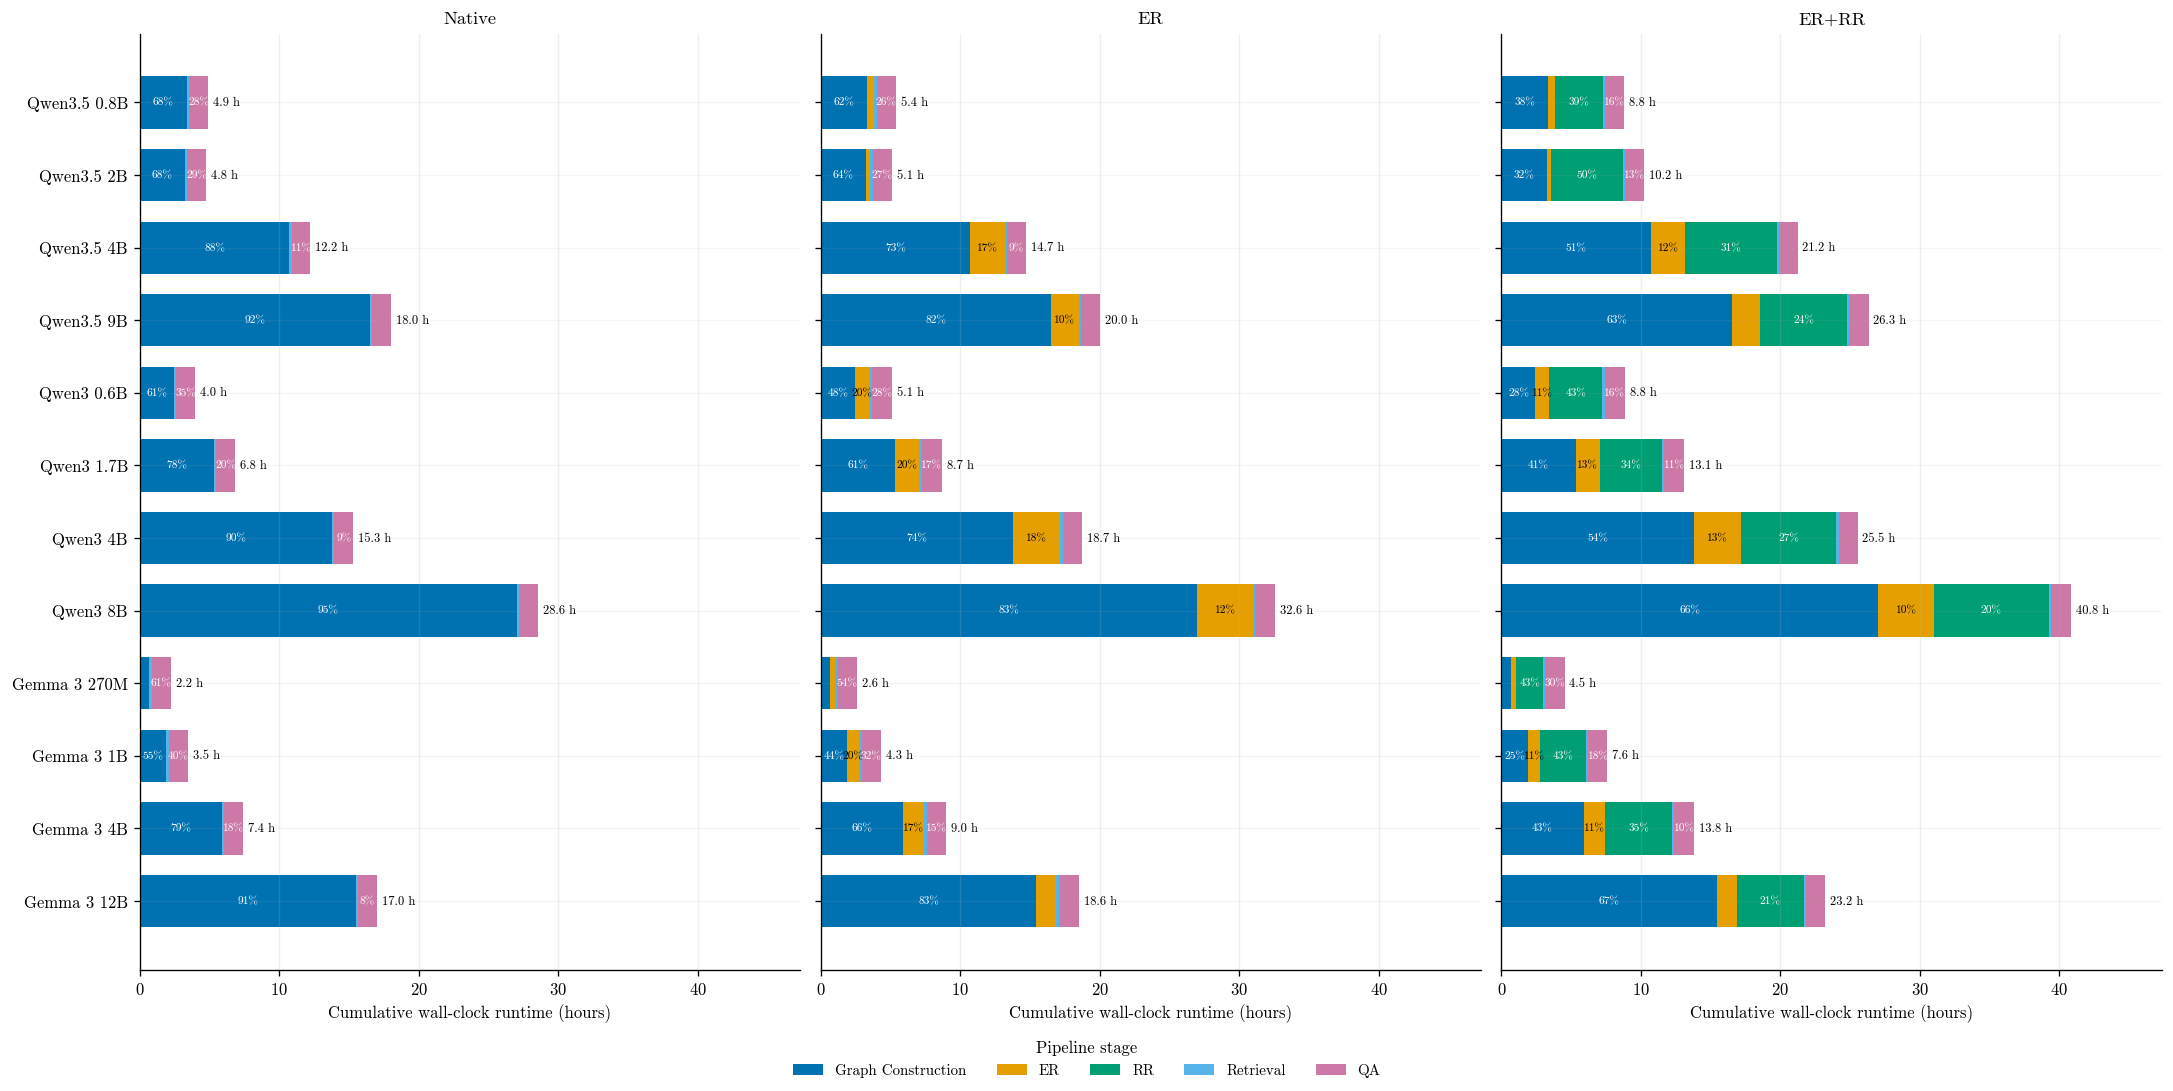

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 9), sharex=True, sharey=True, constrained_layout=True)
y = np.arange(len(display_order))
for ax, regime in zip(axes, REGIME_ORDER):
    subset = stage_efficiency.loc[stage_efficiency["regime"].eq(regime)].copy()
    totals = (
        subset.groupby("display_name", observed=True)["duration_hours"].sum()
        .reindex(display_order).to_numpy()
    )
    left = np.zeros(len(display_order))
    for stage in STAGE_ORDER:
        values = (
            subset.loc[subset["stage"].eq(stage)]
            .set_index("display_name").reindex(display_order)["duration_hours"].fillna(0).to_numpy()
        )
        ax.barh(y, values, left=left, color=STAGE_COLORS[stage], label=stage, height=0.72)
        shares_now = np.divide(values, totals, out=np.zeros_like(values), where=totals > 0)
        text_color = "black" if stage in {"ER", "Retrieval"} else "white"
        for row, (start_value, width, share) in enumerate(zip(left, values, shares_now)):
            if share >= 0.08 and width >= 0.80:
                ax.text(start_value + width / 2, row, f"{share:.0%}", ha="center", va="center", fontsize=6.8, color=text_color)
        left += values
    for row, total in enumerate(left):
        ax.text(total + 0.35, row, f"{total:.1f} h", va="center", fontsize=7.5)
    ax.set_title(regime)
    ax.set_xlabel("Cumulative wall-clock runtime (hours)")
    ax.set_yticks(y, display_order)
    ax.invert_yaxis()
    ax.grid(axis="y", alpha=0.10)
max_total = stage_efficiency.groupby(["builder_key", "regime"], observed=True)["duration_hours"].sum().max()
for ax in axes:
    ax.set_xlim(0, max_total * 1.16)
handles = [Patch(facecolor=STAGE_COLORS[stage], label=stage) for stage in STAGE_ORDER]
fig.legend(handles=handles, loc="outside lower center", ncol=5, frameon=False, title="Pipeline stage")
save_figure(fig, "01_cumulative_stage_runtime")
plt.show()

stage_share_table = stage_efficiency.pivot_table(
    index=["builder_key", "display_name", "family", "parameter_billions", "regime"],
    columns="stage", values="stage_share", observed=True,
).reset_index()
save_table(stage_share_table, "stage_share_by_builder_and_regime")


## Figure 4.6.2 — Within-family throughput scaling

To compare unlike stages on one readable scale, throughput is normalized to the smallest builder in each family (1.0). Values below 1 mean that the larger builder processed the fixed workload more slowly. Retrieval and QA use fixed query/answer models across builders, so their near-flat curves are an important control: builder size should mainly affect construction and post-processing, not query generation.

The accompanying table reports descriptive log–log slopes and endpoint ratios from four builders per family. These are scaling summaries, not inferential estimates. Measured peak-memory scaling is unavailable and remains explicitly missing.


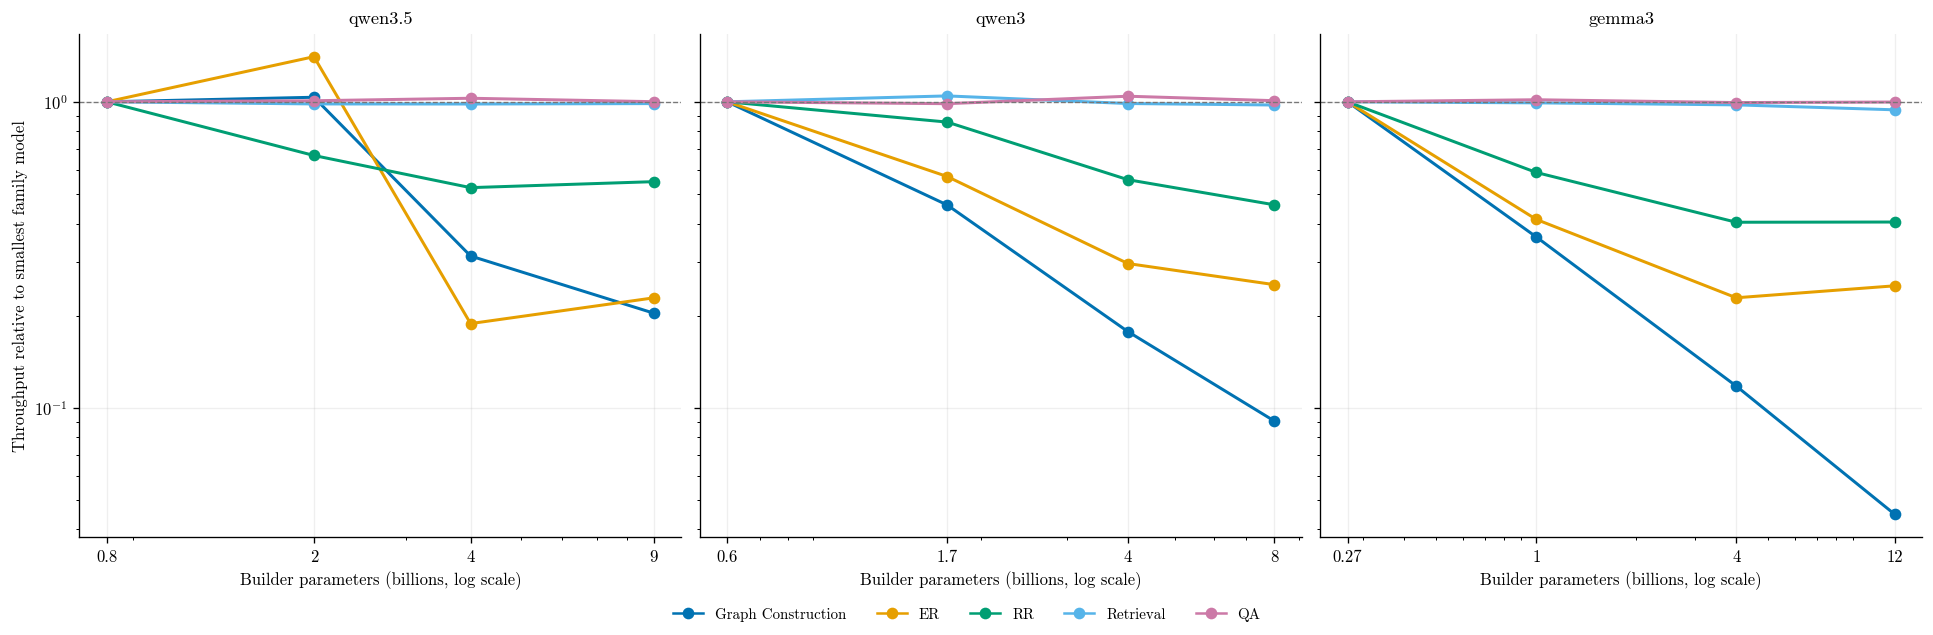

,family,stage,builders,smallest_parameter_billions,largest_parameter_billions,runtime_log_log_slope,throughput_log_log_slope,runtime_large_to_small_ratio,throughput_large_to_small_ratio,r_squared,peak_memory_available
0,qwen3.5,Graph Construction,4,0.8000,9.0000,0.7338,-0.7338,4.9097,0.2037,0.8397,False
1,qwen3.5,ER,4,0.8000,9.0000,0.7812,-0.7812,4.3733,0.2287,0.6221,False
2,qwen3.5,RR,4,0.8000,9.0000,0.2594,-0.2594,1.8239,0.5483,0.8203,False
3,qwen3.5,Retrieval,4,0.8000,9.0000,0.0053,-0.0053,1.0134,0.9868,0.4934,False
4,qwen3.5,QA,4,0.8000,9.0000,-0.0027,0.0027,0.9990,1.0010,0.0503,False
5,qwen3,Graph Construction,4,0.6000,8.0000,0.9406,-0.9406,11.0510,0.0905,0.9928,False
6,qwen3,ER,4,0.6000,8.0000,0.5593,-0.5593,3.9601,0.2525,0.9758,False
7,qwen3,RR,4,0.6000,8.0000,0.3163,-0.3163,2.1711,0.4606,0.9503,False
8,qwen3,Retrieval,4,0.6000,8.0000,0.0135,-0.0135,1.0243,0.9763,0.2541,False
9,qwen3,QA,4,0.6000,8.0000,-0.0098,0.0098,0.9915,1.0086,0.2113,False


In [5]:
scaling_source = stage_efficiency.loc[stage_efficiency["regime"].eq("ER+RR") & stage_efficiency["applicable"]].copy()
scaling_rows = []
for family in FAMILY_COLORS:
    for stage in STAGE_ORDER:
        group = scaling_source.loc[
            scaling_source["family"].eq(family) & scaling_source["stage"].eq(stage)
        ].sort_values("parameter_billions")
        x = np.log(group["parameter_billions"].to_numpy(dtype=float))
        y = np.log(group["duration_seconds"].to_numpy(dtype=float))
        slope, intercept = np.polyfit(x, y, 1)
        fitted = intercept + slope * x
        ss_res = float(np.sum((y - fitted) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        scaling_rows.append({
            "family": family,
            "stage": stage,
            "builders": len(group),
            "smallest_parameter_billions": group["parameter_billions"].iloc[0],
            "largest_parameter_billions": group["parameter_billions"].iloc[-1],
            "runtime_log_log_slope": slope,
            "throughput_log_log_slope": -slope,
            "runtime_large_to_small_ratio": group["duration_seconds"].iloc[-1] / group["duration_seconds"].iloc[0],
            "throughput_large_to_small_ratio": group["duration_seconds"].iloc[0] / group["duration_seconds"].iloc[-1],
            "r_squared": 1 - ss_res / ss_tot if ss_tot > 0 else np.nan,
            "peak_memory_available": False,
        })
family_scaling = pd.DataFrame(scaling_rows)
save_table(family_scaling, "family_model_size_scaling")

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharey=True, constrained_layout=True)
for ax, family in zip(axes, FAMILY_COLORS):
    family_frame = scaling_source.loc[scaling_source["family"].eq(family)]
    for stage in STAGE_ORDER:
        group = family_frame.loc[family_frame["stage"].eq(stage)].sort_values("parameter_billions")
        relative_throughput = group["duration_seconds"].iloc[0] / group["duration_seconds"]
        ax.plot(
            group["parameter_billions"], relative_throughput,
            marker="o", linewidth=1.8, color=STAGE_COLORS[stage], label=stage,
        )
    ax.axhline(1, color="#777777", linewidth=0.8, linestyle="--")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(family)
    ax.set_xlabel("Builder parameters (billions, log scale)")
    ax.set_xticks(sorted(family_frame["parameter_billions"].unique()))
    ax.set_xticklabels([f"{value:g}" for value in sorted(family_frame["parameter_billions"].unique())])
axes[0].set_ylabel("Throughput relative to smallest family model")
fig.legend(
    handles=[Line2D([0], [0], color=STAGE_COLORS[stage], marker="o", label=stage) for stage in STAGE_ORDER],
    loc="outside lower center", ncol=5, frameon=False,
)
save_figure(fig, "02_within_family_throughput_scaling")
plt.show()
display(family_scaling)


## Figure 4.6.3 — Quality–efficiency trade-offs

The x-axis includes setup and query costs for the complete fixed workload, so a point is operationally meaningful rather than merely a per-request latency result. Higher and farther left is better. Pale lines connect Native → ER → ER+RR for the same builder; labels identify only Pareto-efficient points. MRR is computed over answerable questions, while QA accuracy uses all 120 questions.


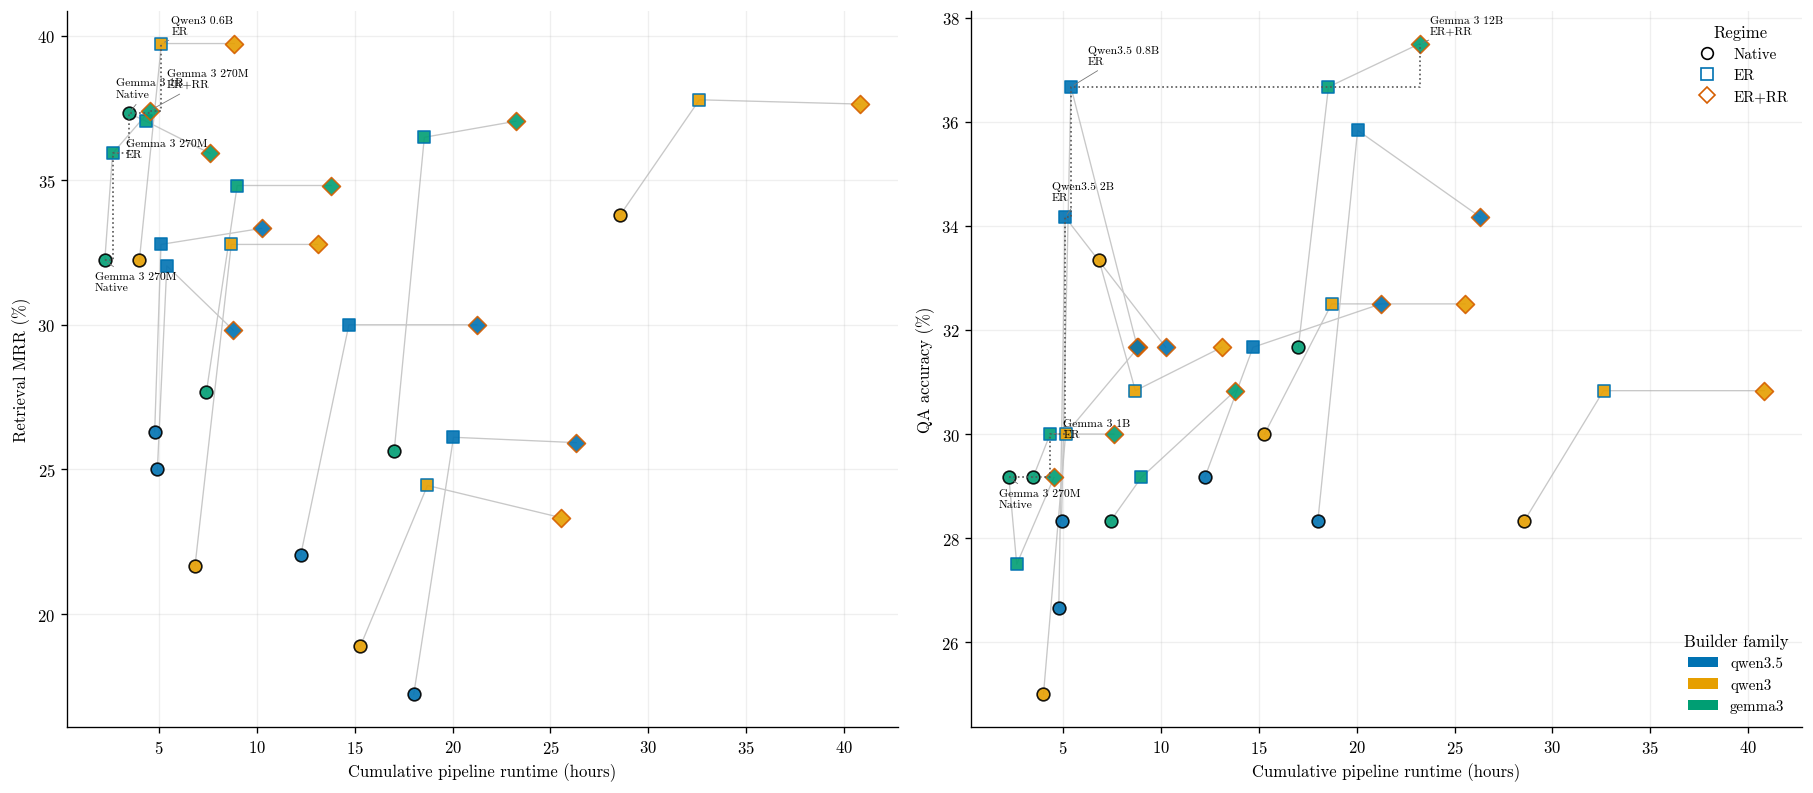

In [6]:
tradeoff = practical_summary.copy()

def pareto_mask(cost: pd.Series, quality: pd.Series) -> np.ndarray:
    order = np.argsort(cost.to_numpy(dtype=float))
    keep = np.zeros(len(cost), dtype=bool)
    best = -np.inf
    for position in order:
        value = float(quality.iloc[position])
        if value > best + 1e-12:
            keep[position] = True
            best = value
    return keep

tradeoff["qa_pareto"] = pareto_mask(tradeoff["total_pipeline_hours"], tradeoff["qa_accuracy"])
tradeoff["mrr_pareto"] = pareto_mask(tradeoff["total_pipeline_hours"], tradeoff["retrieval_mrr"])
save_table(tradeoff, "quality_efficiency_tradeoff")

markers = {"Native": "o", "ER": "s", "ER+RR": "D"}
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), constrained_layout=True)
for ax, metric, label, pareto_col in [
    (axes[0], "retrieval_mrr", "Retrieval MRR (%)", "mrr_pareto"),
    (axes[1], "qa_accuracy", "QA accuracy (%)", "qa_pareto"),
]:
    for builder in builder_order:
        group = tradeoff.loc[tradeoff["builder_key"].astype(str).eq(builder)].set_index("regime").reindex(REGIME_ORDER)
        ax.plot(group["total_pipeline_hours"], group[metric] * 100, color="#C8C8C8", linewidth=0.8, zorder=1)
    for regime in REGIME_ORDER:
        for family, group in tradeoff.loc[tradeoff["regime"].eq(regime)].groupby("family", observed=True):
            ax.scatter(
                group["total_pipeline_hours"], group[metric] * 100,
                s=58, marker=markers[regime], color=FAMILY_COLORS[family],
                edgecolor=REGIME_COLORS[regime], linewidth=1.0, alpha=0.90, zorder=2,
            )
    frontier = tradeoff.loc[tradeoff[pareto_col]].copy()
    frontier = frontier.sort_values("total_pipeline_hours")
    ax.step(frontier["total_pipeline_hours"], frontier[metric] * 100, where="post", color="#555555", linewidth=1.0, linestyle=":")
    label_offsets = [(-6, -18), (8, -2), (-8, 10), (10, 14), (6, 6)]
    for label_index, row in enumerate(frontier.itertuples(index=False)):
        ax.annotate(
            f"{row.display_name}\n{row.regime}",
            (row.total_pipeline_hours, getattr(row, metric) * 100),
            xytext=label_offsets[label_index % len(label_offsets)], textcoords="offset points", fontsize=7,
            arrowprops={"arrowstyle": "-", "color": "#777777", "linewidth": 0.5},
        )
    ax.set_xlabel("Cumulative pipeline runtime (hours)")
    ax.set_ylabel(label)
family_handles = [Patch(facecolor=color, label=family) for family, color in FAMILY_COLORS.items()]
regime_handles = [Line2D([0], [0], marker=markers[regime], color="none", markeredgecolor=REGIME_COLORS[regime], label=regime, markersize=7) for regime in REGIME_ORDER]
legend1 = axes[1].legend(handles=family_handles, title="Builder family", frameon=False, loc="lower right")
axes[1].add_artist(legend1)
axes[1].legend(handles=regime_handles, title="Regime", frameon=False, loc="upper right")
save_figure(fig, "03_quality_efficiency_frontiers")
plt.show()


## Hardware, memory, saturation, and practical constraints

The runs used local Ollama inference with Q4-quantized builders on Apple Silicon. The answer, keyword, and query roles were fixed to Gemma 3 12B, and the embedding model was fixed to Qwen3-Embedding 0.6B; consequently, Retrieval and QA are primarily shared-system costs rather than builder-size costs.

The lifecycle deliberately unloads unrelated resident runners between stages to reduce non-deterministic memory pressure. However, neither peak RSS nor peak unified-memory use was recorded per stage. Therefore:

- peak-memory curves and memory-throughput scaling cannot be estimated from these artifacts;
- a retry or long duration is not labeled as OOM or saturation without a recorded OOM event;
- the 16 GB host is reported as a capacity constraint, not as measured stage consumption;
- `attempt_count > 1` is reported only as operational retry pressure.


In [7]:
def system_profiler_hardware() -> dict:
    fields = {"Model Name": None, "Model Identifier": None, "Chip": None, "Total Number of Cores": None, "Memory": None}
    if platform.system() != "Darwin":
        return fields
    try:
        completed = subprocess.run(
            ["system_profiler", "SPHardwareDataType"], check=False,
            capture_output=True, text=True, timeout=30,
        )
        for line in completed.stdout.splitlines():
            stripped = line.strip()
            for key in fields:
                if stripped.startswith(f"{key}:"):
                    fields[key] = stripped.split(":", 1)[1].strip()
    except (OSError, subprocess.TimeoutExpired):
        pass
    return fields

host = system_profiler_hardware()
active_lifecycle_ids = set(active_variant_map) | set(base_map)
oom_pattern = re.compile(r"\bOOM\b|out of memory|memory exhausted", flags=re.IGNORECASE)
explicit_oom_in_active_lifecycle = any(
    record.get("item_id") in active_lifecycle_ids
    and oom_pattern.search(" ".join(str(record.get(field) or "") for field in ("error_type", "message")))
    for record in status_report["records"].values()
)
hardware_resource_context = pd.DataFrame([{
    "host_model": host["Model Name"],
    "host_identifier": host["Model Identifier"],
    "chip": host["Chip"],
    "cpu_cores": host["Total Number of Cores"],
    "installed_unified_memory": host["Memory"],
    "platform_recorded_in_run": model_resource_context["platform"].mode().iat[0],
    "builder_quantization": ", ".join(sorted(model_resource_context["quantization"].dropna().unique())),
    "builder_parameter_range_billions": f"{builder_meta['parameter_billions'].min():g}–{builder_meta['parameter_billions'].max():g}",
    "fixed_query_answer_model": "Gemma 3 12B Q4_K_M",
    "fixed_embedding_model": "Qwen3-Embedding 0.6B Q8_0",
    "peak_rss_or_unified_memory_recorded": False,
    "explicit_oom_event_in_active_lifecycle": explicit_oom_in_active_lifecycle,
    "resource_interpretation": "capacity context only; no per-stage peak-memory measurement",
}])
save_table(hardware_resource_context, "hardware_resource_context")
display(hardware_resource_context)
display(model_resource_context)


,host_model,host_identifier,chip,cpu_cores,installed_unified_memory,platform_recorded_in_run,builder_quantization,builder_parameter_range_billions,fixed_query_answer_model,fixed_embedding_model,peak_rss_or_unified_memory_recorded,explicit_oom_event_in_active_lifecycle,resource_interpretation
0,MacBook Pro,"MacBookPro18,1",Apple M1 Pro,10 (8 Performance and 2 Efficiency),16 GB,macOS-26.5.2-arm64-arm-64bit-Mach-O,Q4_K_M,0.27–12,Gemma 3 12B Q4_K_M,Qwen3-Embedding 0.6B Q8_0,False,False,capacity context only; no per-stage peak-memory measurement


,builder_key,display_name,family,parameter_billions,requested_model,recorded_parameter_size,quantization,builder_context_length,platform,ollama_version,environment_path,recorded_peak_memory_gb,memory_measurement
0,qwen35_0_8b,Qwen3.5 0.8B,qwen3.5,0.8000,hf.co/lmstudio-community/Qwen3.5-0.8B-GGUF:Q4_K_M,752M,Q4_K_M,262144,macOS-26.5.2-arm64-arm-64bit-Mach-O,ollama version is 0.30.7,runs/base/base_83aca3d6aa4f4a035bf5d21c/b-hf-co-lmstudio-community-qwen3-5-0-8b-gguf-q4-k__q-q4-...,NaN,not instrumented
1,qwen35_2b,Qwen3.5 2B,qwen3.5,2.0000,hf.co/lmstudio-community/Qwen3.5-2B-GGUF:Q4_K_M,1.88B,Q4_K_M,262144,macOS-26.5.2-arm64-arm-64bit-Mach-O,ollama version is 0.30.7,runs/base/base_6ff2fb588647938593c42b5a/b-hf-co-lmstudio-community-qwen3-5-2b-gguf-q4-k-m__q-q4-...,NaN,not instrumented
2,qwen35_4b,Qwen3.5 4B,qwen3.5,4.0000,hf.co/lmstudio-community/Qwen3.5-4B-GGUF:Q4_K_M,4.21B,Q4_K_M,262144,macOS-26.5.2-arm64-arm-64bit-Mach-O,ollama version is 0.30.7,runs/base/base_fade67868ef8d6d4b7d790eb/b-hf-co-lmstudio-community-qwen3-5-4b-gguf-q4-k-m__q-q4-...,NaN,not instrumented
3,qwen35_9b,Qwen3.5 9B,qwen3.5,9.0000,hf.co/lmstudio-community/Qwen3.5-9B-GGUF:Q4_K_M,8.95B,Q4_K_M,262144,macOS-26.5.2-arm64-arm-64bit-Mach-O,ollama version is 0.30.7,runs/base/base_098496a4a666032d4809338b/b-hf-co-lmstudio-community-qwen3-5-9b-gguf-q4-k-m__q-q4-...,NaN,not instrumented
4,qwen3_0_6b,Qwen3 0.6B,qwen3,0.6000,hf.co/lmstudio-community/Qwen3-0.6B-GGUF:Q4_K_M,752M,Q4_K_M,40960,macOS-26.5.2-arm64-arm-64bit-Mach-O,ollama version is 0.30.7,runs/base/base_084b5c3ad8d7434afbe4e74f/b-hf-co-lmstudio-community-qwen3-0-6b-gguf-q4-k-m__q-q4-...,NaN,not instrumented
5,qwen3_1_7b,Qwen3 1.7B,qwen3,1.7000,hf.co/lmstudio-community/Qwen3-1.7B-GGUF:Q4_K_M,2.03B,Q4_K_M,32768,macOS-26.5.2-arm64-arm-64bit-Mach-O,ollama version is 0.30.7,runs/base/base_0d6955c37af628650e9654ec/b-hf-co-lmstudio-community-qwen3-1-7b-gguf-q4-k-m__q-q4-...,NaN,not instrumented
6,qwen3_4b,Qwen3 4B,qwen3,4.0000,hf.co/lmstudio-community/Qwen3-4B-GGUF:Q4_K_M,4.02B,Q4_K_M,32768,macOS-26.5.2-arm64-arm-64bit-Mach-O,ollama version is 0.30.7,runs/base/base_97ba3cce02889beea444bd79/b-hf-co-lmstudio-community-qwen3-4b-gguf-q4-k-m__q-q4-k-...,NaN,not instrumented
7,qwen3_8b,Qwen3 8B,qwen3,8.0000,hf.co/lmstudio-community/Qwen3-8B-GGUF:Q4_K_M,8.19B,Q4_K_M,32768,macOS-26.5.2-arm64-arm-64bit-Mach-O,ollama version is 0.30.7,runs/base/base_541d8b1af2513e6db17b19e0/b-hf-co-lmstudio-community-qwen3-8b-gguf-q4-k-m__q-q4-k-...,NaN,not instrumented
8,gemma3_270m,Gemma 3 270M,gemma3,0.2700,hf.co/lmstudio-community/gemma-3-270m-it-GGUF:Q4_K_M,268M,Q4_K_M,32768,macOS-26.5.2-arm64-arm-64bit-Mach-O,ollama version is 0.30.7,runs/base/base_91358cb1f88dec176a28953b/b-hf-co-lmstudio-community-gemma-3-270m-it-gguf-q4__q-q4...,NaN,not instrumented
9,gemma3_1b,Gemma 3 1B,gemma3,1.0000,hf.co/lmstudio-community/gemma-3-1b-it-GGUF:Q4_K_M,"1,000M",Q4_K_M,32768,macOS-26.5.2-arm64-arm-64bit-Mach-O,ollama version is 0.30.7,runs/base/base_85df22828efa71c2b6754a25/b-hf-co-lmstudio-community-gemma-3-1b-it-gguf-q4-k__q-q4...,NaN,not instrumented


## Practical findings generated from the active artifacts

The following summary is computed from the same exported tables, keeping numerical claims synchronized with the notebook inputs.


In [8]:
stage_totals = stage_efficiency.groupby(["regime", "stage"], observed=True)["duration_seconds"].sum()
regime_bottlenecks = stage_totals / stage_totals.groupby(level=0).transform("sum")
lines = []
for regime in REGIME_ORDER:
    shares_regime = regime_bottlenecks.loc[regime].sort_values(ascending=False)
    lines.append(
        f"- **{regime}:** {shares_regime.index[0]} is the dominant aggregate stage "
        f"({shares_regime.iloc[0]:.1%} of builder-summed cumulative runtime); "
        f"the next largest is {shares_regime.index[1]} ({shares_regime.iloc[1]:.1%})."
    )

largest_ratios = family_scaling.loc[family_scaling["stage"].eq("Graph Construction")]
for row in largest_ratios.itertuples(index=False):
    lines.append(
        f"- **{row.family} construction scaling:** the largest model took "
        f"{row.runtime_large_to_small_ratio:.2f}× the wall-clock time of the smallest family model "
        f"for the same 440 chunks (descriptive endpoint ratio)."
    )

best_qa = tradeoff.loc[tradeoff["qa_accuracy"].idxmax()]
best_mrr = tradeoff.loc[tradeoff["retrieval_mrr"].idxmax()]
fastest = tradeoff.loc[tradeoff["total_pipeline_hours"].idxmin()]
retrying = tradeoff.loc[tradeoff["retry_excess"].gt(0)]
most_retries = retrying.loc[retrying["retry_excess"].idxmax()] if len(retrying) else None
lines.extend([
    f"- **Highest QA accuracy:** {best_qa['display_name']} / {best_qa['regime']} "
    f"at {best_qa['qa_accuracy']:.1%}, costing {best_qa['total_pipeline_hours']:.1f} cumulative hours.",
    f"- **Highest retrieval MRR:** {best_mrr['display_name']} / {best_mrr['regime']} "
    f"at {best_mrr['retrieval_mrr']:.1%}, costing {best_mrr['total_pipeline_hours']:.1f} cumulative hours.",
    f"- **Lowest cumulative runtime:** {fastest['display_name']} / {fastest['regime']} "
    f"at {fastest['total_pipeline_hours']:.1f} hours, with {fastest['qa_accuracy']:.1%} QA accuracy "
    f"and {fastest['retrieval_mrr']:.1%} retrieval MRR.",
    (f"- **Operational retry pressure:** {len(retrying)} of 36 cumulative configurations include at least one excess attempt; "
     f"the largest count is {most_retries['retry_excess']:.0f} for {most_retries['display_name']} / {most_retries['regime']}. "
     f"No explicit OOM event is recorded in the active lifecycle.") if most_retries is not None else "- **Operational retry pressure:** none recorded.",
    "- **Memory conclusion:** model-size memory scaling is not identifiable because peak memory was not recorded. "
    "The 16 GB unified-memory host and runner-unloading policy establish a real capacity constraint, but not a measured memory curve or an OOM attribution.",
])
display(Markdown("\n".join(lines)))


- **Native:** Graph Construction is the dominant aggregate stage (85.3% of builder-summed cumulative runtime); the next largest is QA (13.1%).
- **ER:** Graph Construction is the dominant aggregate stage (73.4% of builder-summed cumulative runtime); the next largest is ER (13.5%).
- **ER+RR:** Graph Construction is the dominant aggregate stage (52.1% of builder-summed cumulative runtime); the next largest is RR (29.1%).
- **qwen3.5 construction scaling:** the largest model took 4.91× the wall-clock time of the smallest family model for the same 440 chunks (descriptive endpoint ratio).
- **qwen3 construction scaling:** the largest model took 11.05× the wall-clock time of the smallest family model for the same 440 chunks (descriptive endpoint ratio).
- **gemma3 construction scaling:** the largest model took 22.30× the wall-clock time of the smallest family model for the same 440 chunks (descriptive endpoint ratio).
- **Highest QA accuracy:** Gemma 3 12B / ER+RR at 37.5%, costing 23.2 cumulative hours.
- **Highest retrieval MRR:** Qwen3 0.6B / ER at 39.7%, costing 5.1 cumulative hours.
- **Lowest cumulative runtime:** Gemma 3 270M / Native at 2.2 hours, with 29.2% QA accuracy and 32.2% retrieval MRR.
- **Operational retry pressure:** 10 of 36 cumulative configurations include at least one excess attempt; the largest count is 4 for Qwen3.5 2B / ER. No explicit OOM event is recorded in the active lifecycle.
- **Memory conclusion:** model-size memory scaling is not identifiable because peak memory was not recorded. The 16 GB unified-memory host and runner-unloading policy establish a real capacity constraint, but not a measured memory curve or an OOM attribution.

In [9]:
required_tables = [
    "source_validation", "source_inventory", "model_resource_context",
    "pipeline_stage_efficiency_long", "practical_efficiency_by_builder_and_regime",
    "request_efficiency_by_builder_and_regime", "stage_share_by_builder_and_regime",
    "family_model_size_scaling", "quality_efficiency_tradeoff", "hardware_resource_context",
]
required_figures = [
    "01_cumulative_stage_runtime",
    "02_within_family_throughput_scaling",
    "03_quality_efficiency_frontiers",
]
for stem in required_tables:
    for suffix in (".csv", ".tex"):
        path = OUTPUT_DIR / f"{stem}{suffix}"
        if not path.is_file() or path.stat().st_size == 0:
            raise AssertionError(f"Missing or empty output: {path}")
for stem in required_figures:
    for suffix in (".png", ".svg"):
        path = OUTPUT_DIR / f"{stem}{suffix}"
        if not path.is_file() or path.stat().st_size == 0:
            raise AssertionError(f"Missing or empty output: {path}")
assert practical_summary.shape[0] == 36
assert family_scaling.shape[0] == 15
assert not stage_efficiency.loc[stage_efficiency["applicable"], "seconds_per_unit"].isna().any()
print("FINAL_AUDIT_OK")
print(f"Tables: {len(required_tables)} CSV + {len(required_tables)} LaTeX; figures: {len(required_figures)} PNG + {len(required_figures)} SVG")


FINAL_AUDIT_OK
Tables: 10 CSV + 10 LaTeX; figures: 3 PNG + 3 SVG
